In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('events.csv')
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [ ]:
df.shape

(2756101, 9)

In [ ]:
print(df["event"].value_counts())

print("\nUnique events:")
print(df["event"].unique())

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Unique events:
['view' 'addtocart' 'transaction']


In [ ]:
print(df["visitorid"].value_counts())

print("\nUnique ids:")
print(df["visitorid"].unique())

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
           ... 
548017        1
548016        1
548015        1
548014        1
548023        1
Name: count, Length: 1407580, dtype: int64

Unique ids:
[      0       1       2 ... 1407577 1407578 1407579]


In [ ]:
visitor_counts = df["visitorid"].value_counts()

print(visitor_counts)

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
           ... 
548017        1
548016        1
548015        1
548014        1
548023        1
Name: count, Length: 1407580, dtype: int64


In [ ]:
event_counts = (
    df.groupby(["visitorid", "event"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

event_counts = event_counts.rename(columns={
    "view": "view_count",
    "addtocart": "addtocart_count",
    "transaction": "transaction_count"
})

display(event_counts.head())

event,visitorid,addtocart_count,transaction_count,view_count
0,0,0,0,3
1,1,0,0,1
2,2,0,0,8
3,3,0,0,1
4,4,0,0,1


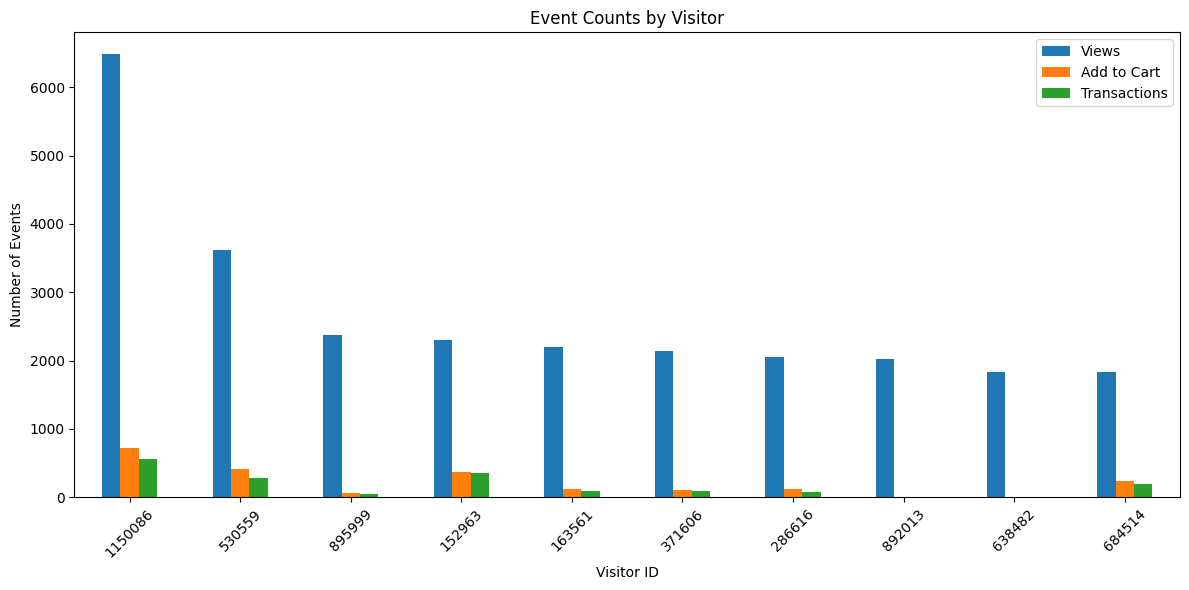

In [ ]:
import matplotlib.pyplot as plt

top_visitors = (
    event_counts
    .sort_values("view_count", ascending=False)
    .head(10)
)

top_visitors.plot(
    x="visitorid",
    y=["view_count", "addtocart_count", "transaction_count"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Event Counts by Visitor")
plt.xlabel("Visitor ID")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.legend(
    ["Views", "Add to Cart", "Transactions"]
)
plt.tight_layout()
plt.show()

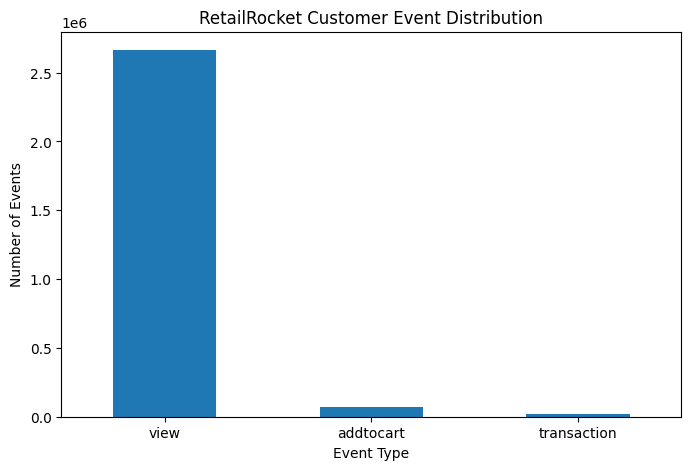

In [ ]:
event_counts = df["event"].value_counts()

plt.figure(figsize=(8, 5))
event_counts.plot(kind="bar")
plt.title("RetailRocket Customer Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.show()

In [ ]:
event_mapping = {
    "view": 1,
    "addtocart": 2,
    "transaction": 3
}

reverse_mapping = {
    0: "0",
    1: "view",
    2: "addtocart",
    3: "transaction"
}

df["event_encoded"] = (
    df["event"]
    .map(event_mapping)
    .astype("int8")
)

display(
    df[
        ["visitorid", "timestamp", "event", "event_encoded", "itemid"]
    ].head(15)
)

,visitorid,timestamp,event,event_encoded,itemid
0,257597,1433221332117,view,1,355908
1,992329,1433224214164,view,1,248676
2,111016,1433221999827,view,1,318965
3,483717,1433221955914,view,1,253185
4,951259,1433221337106,view,1,367447
5,972639,1433224086234,view,1,22556
6,810725,1433221923240,view,1,443030
7,794181,1433223291897,view,1,439202
8,824915,1433220899221,view,1,428805
9,339335,1433221204592,view,1,82389


In [ ]:
df = df.sort_values(
    ["visitorid", "timestamp"],
    kind="mergesort"
).reset_index(drop=True)

print("Data sorted by visitor and timestamp.")

first_visitor = df["visitorid"].iloc[0]

display(
    df[df["visitorid"] == first_visitor][
        ["visitorid", "timestamp", "event", "event_encoded", "itemid"]
    ].head(20)
)

Data sorted by visitor and timestamp.


,visitorid,timestamp,event,event_encoded,itemid
0,0,1442004589439,view,1,285930
1,0,1442004759591,view,1,357564
2,0,1442004917175,view,1,67045


In [ ]:
df["is_view"] = (df["event"] == "view").astype("int8")
df["is_cart"] = (df["event"] == "addtocart").astype("int8")
df["is_transaction"] = (df["event"] == "transaction").astype("int8")

customer_features = (
    df.groupby("visitorid", sort=False)
      .agg(
          total_interactions=("event", "size"),
          view_count=("is_view", "sum"),
          cart_count=("is_cart", "sum"),
          transaction_count=("is_transaction", "sum"),
          unique_items=("itemid", "nunique")
      )
      .reset_index()
)

print("Customer feature shape:", customer_features.shape)
display(customer_features.head(10))

Customer feature shape: (1407580, 6)


,visitorid,total_interactions,view_count,cart_count,transaction_count,unique_items
0,0,3,3,0,0,3
1,1,1,1,0,0,1
2,2,8,8,0,0,4
3,3,1,1,0,0,1
4,4,1,1,0,0,1
5,5,1,1,0,0,1
6,6,6,5,1,0,3
7,7,3,3,0,0,3
8,8,1,1,0,0,1
9,9,1,1,0,0,1


In [ ]:
def assign_behavior(row):

    if row["cart_count"] == 0 and row["transaction_count"] == 0:
        return 0       # Explorer

    elif row["transaction_count"] == 0:
        return 1       # Interested

    else:
        return 2       # Intent-driven


customer_features["behavior_label"] = (
    customer_features.apply(assign_behavior, axis=1)
)

In [ ]:
behavior_names = {
    0: "Explorer",
    1: "Interested",
    2: "Intent-driven"
}

customer_features["behavior"] = (
    customer_features["behavior_label"]
    .map(behavior_names)
)

print(
    customer_features["behavior"]
    .value_counts()
)

display(
    customer_features.head(15)
)

behavior
Explorer         1368715
Interested         27146
Intent-driven      11719
Name: count, dtype: int64


,visitorid,total_interactions,view_count,cart_count,transaction_count,unique_items,behavior_label,behavior
0,0,3,3,0,0,3,0,Explorer
1,1,1,1,0,0,1,0,Explorer
2,2,8,8,0,0,4,0,Explorer
3,3,1,1,0,0,1,0,Explorer
4,4,1,1,0,0,1,0,Explorer
5,5,1,1,0,0,1,0,Explorer
6,6,6,5,1,0,3,1,Interested
7,7,3,3,0,0,3,0,Explorer
8,8,1,1,0,0,1,0,Explorer
9,9,1,1,0,0,1,0,Explorer


behavior
Explorer         1368715
Intent-driven      11719
Interested         27146
Name: count, dtype: int64


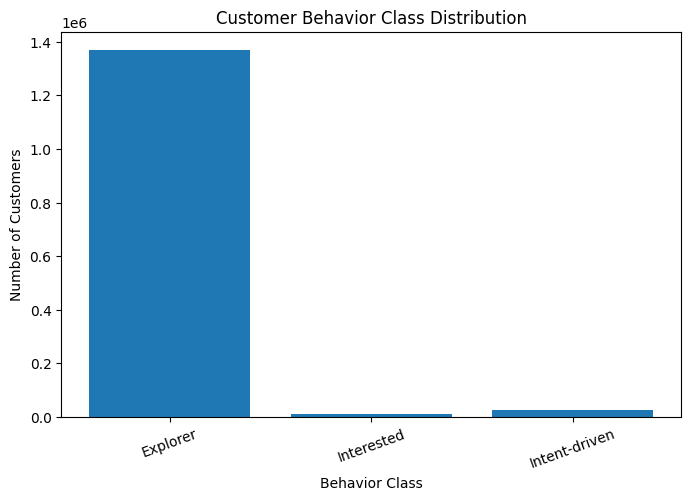

In [ ]:
import matplotlib.pyplot as plt

class_counts = (
    customer_features["behavior"]
    .value_counts()
    .sort_index()
)

print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    ["Explorer", "Interested", "Intent-driven"],
    class_counts.values
)
plt.xlabel("Behavior Class")
plt.ylabel("Number of Customers")
plt.title("Customer Behavior Class Distribution")
plt.xticks(rotation=20)
plt.show()

In [ ]:
MAX_LEN = 20

sequence_dict = (
    df.groupby("visitorid", sort=False)["event_encoded"]
      .agg(list)
)

visitor_ids = customer_features["visitorid"].values

sequences = [
    sequence_dict.get(visitor_id, [])
    for visitor_id in visitor_ids
]

print("Number of sequences:", len(sequences))

Number of sequences: 1407580


In [ ]:
purchase_visitors = df.loc[
    df["event_encoded"] == 3,
    "visitorid"
].unique()

y_purchase = np.isin(
    visitor_ids,
    purchase_visitors
).astype("int8")

print("y_purchase shape:", y_purchase.shape)

print("\nPurchase class distribution:")
print(
    pd.Series(y_purchase)
    .value_counts()
    .rename(index={
        0: "No Purchase",
        1: "Purchase"
    })
)

y_purchase shape: (1407580,)

Purchase class distribution:
No Purchase    1395861
Purchase         11719
Name: count, dtype: int64


In [ ]:
y_behavior = customer_features["behavior_label"].to_numpy()

print("y_behavior shape:", y_behavior.shape)

print("\nBehavior class distribution:")

for label, name in behavior_names.items():
    count = np.sum(y_behavior == label)
    print(f"{label} - {name}: {count:,}")

y_behavior shape: (1407580,)

Behavior class distribution:
0 - Explorer: 1,368,715
1 - Interested: 27,146
2 - Intent-driven: 11,719


In [ ]:
sequences = [
    sequence_dict.get(visitor_id, [])
    for visitor_id in visitor_ids
]

In [ ]:
print("Number of visitors :", len(visitor_ids))
print("Number of sequences:", len(sequences))
print("Behavior labels    :", len(y_behavior))
print("Purchase labels    :", len(y_purchase))

assert len(visitor_ids) == len(sequences)
assert len(visitor_ids) == len(y_behavior)
assert len(visitor_ids) == len(y_purchase)

print("\n✓ All data are correctly aligned")

Number of visitors : 1407580
Number of sequences: 1407580
Behavior labels    : 1407580
Purchase labels    : 1407580

✓ All data are correctly aligned


In [ ]:
for i in range(10):
    print(
        f"Sample {i+1}:",
        f"Visitor={visitor_ids[i]}",
        f"Sequence={sequences[i]}",
        f"Behavior={y_behavior[i]}",
        f"Purchase={y_purchase[i]}"
    )

Sample 1: Visitor=0 Sequence=[1, 1, 1] Behavior=0 Purchase=0
Sample 2: Visitor=1 Sequence=[1] Behavior=0 Purchase=0
Sample 3: Visitor=2 Sequence=[1, 1, 1, 1, 1, 1, 1, 1] Behavior=0 Purchase=0
Sample 4: Visitor=3 Sequence=[1] Behavior=0 Purchase=0
Sample 5: Visitor=4 Sequence=[1] Behavior=0 Purchase=0
Sample 6: Visitor=5 Sequence=[1] Behavior=0 Purchase=0
Sample 7: Visitor=6 Sequence=[2, 1, 1, 1, 1, 1] Behavior=1 Purchase=0
Sample 8: Visitor=7 Sequence=[1, 1, 1] Behavior=0 Purchase=0
Sample 9: Visitor=8 Sequence=[1] Behavior=0 Purchase=0
Sample 10: Visitor=9 Sequence=[1] Behavior=0 Purchase=0


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    value=0
)

print("X shape:", X.shape)

for i in range(5):
    decoded = [
        reverse_mapping[value]
        for value in X[i]
    ]

    print(f"\nSequence {i+1}")
    print("Encoded :", X[i])
    print("Decoded :", " → ".join(decoded))

X shape: (1407580, 20)

Sequence 1
Encoded : [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → view → view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 2
Encoded : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 3
Encoded : [1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → view → view → view → view → view → view → view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 4
Encoded : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0

Sequence 5
Encoded : [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Decoded : view → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, \
y_behavior_train, y_behavior_temp, \
y_purchase_train, y_purchase_temp, \
train_customer_ids, temp_customer_ids = train_test_split(
    X,
    y_behavior,
    y_purchase,
    visitor_ids,
    test_size=0.30,
    random_state=42,
    stratify=y_behavior
)

In [ ]:
X_val, X_test, \
y_behavior_val, y_behavior_test, \
y_purchase_val, y_purchase_test, \
val_customer_ids, test_customer_ids = train_test_split(
    X_temp,
    y_behavior_temp,
    y_purchase_temp,
    temp_customer_ids,
    test_size=0.50,
    random_state=42,
    stratify=y_behavior_temp
)

In [ ]:
print("Training:")
print("X:", X_train.shape)
print("Behavior:", y_behavior_train.shape)
print("Purchase:", y_purchase_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("Behavior:", y_behavior_val.shape)
print("Purchase:", y_purchase_val.shape)

print("\nTesting:")
print("X:", X_test.shape)
print("Behavior:", y_behavior_test.shape)
print("Purchase:", y_purchase_test.shape)

Training:
X: (985306, 20)
Behavior: (985306,)
Purchase: (985306,)

Validation:
X: (211137, 20)
Behavior: (211137,)
Purchase: (211137,)

Testing:
X: (211137, 20)
Behavior: (211137,)
Purchase: (211137,)


In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

inputs = Input(shape=(MAX_LEN, 1))

x = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(inputs)

x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(
    filters=128,
    kernel_size=3,
    padding="same",
    activation="relu"
)(x)

x = GlobalMaxPooling1D()(x)

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

behavior_output = Dense(
    3,
    activation="softmax",
    name="behavior"
)(x)

purchase_output = Dense(
    1,
    activation="sigmoid",
    name="purchase"
)(x)



In [ ]:
model = Model(
    inputs=inputs,
    outputs=[behavior_output, purchase_output]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 20, 64)    │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 10, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavior (Dense)    │ (None, 3)         │        195 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ purchase (Dense)    │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,476 (130.77 KB)

 Trainable params: 33,476 (130.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Model(
    inputs=inputs,
    outputs=[
        behavior_output,
        purchase_output
    ]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 10, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavior (Dense)    │ (None, 3)         │        195 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ purchase (Dense)    │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,476 (130.77 KB)

 Trainable params: 33,476 (130.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss={
        "behavior": "sparse_categorical_crossentropy",
        "purchase": "binary_crossentropy"
    },
    metrics={
        "behavior": ["accuracy"],
        "purchase": ["accuracy"]
    }
)

In [ ]:
history = model.fit(
    X_train,
    {
        "behavior": y_behavior_train,
        "purchase": y_purchase_train
    },
    validation_data=(
        X_val,
        {
            "behavior": y_behavior_val,
            "purchase": y_purchase_val
        }
    ),
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
32844/32844 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - behavior_accuracy: 0.9990 - behavior_loss: 0.0033 - loss: 0.0054 - purchase_accuracy: 0.9993 - purchase_loss: 0.0021 - val_behavior_accuracy: 0.9993 - val_behavior_loss: 0.0022 - val_loss: 0.0036 - val_purchase_accuracy: 0.9995 - val_purchase_loss: 0.0014
Epoch 2/10
32844/32844 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - behavior_accuracy: 0.9992 - behavior_loss: 0.0025 - loss: 0.0041 - purchase_accuracy: 0.9994 - purchase_loss: 0.0016 - val_behavior_accuracy: 0.9993 - val_behavior_loss: 0.0021 - val_loss: 0.0035 - val_purchase_accuracy: 0.9995 - val_purchase_loss: 0.0014
Epoch 3/10
32844/32844 ━━━━━━━━━━━━━━━━━━━━ 202s 6ms/step - behavior_accuracy: 0.9992 - behavior_loss: 0.0024 - loss: 0.0040 - purchase_accuracy: 0.9994 - purchase_loss: 0.0016 - val_behavior_accuracy: 0.9993 - val_behavior_loss: 0.0021 - val_loss: 0.0035 - val_purchase_accuracy: 0.9995 - val_purchase_loss: 0.0014
Epoch 4/10
32844/32844 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms

In [ ]:
behavior_prob, purchase_prob = model.predict(X_test)

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


In [ ]:
behavior_pred = np.argmax(
    behavior_prob,
    axis=1
)

In [ ]:
purchase_pred = (
    purchase_prob.ravel() >= 0.5
).astype(int)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

print("Behavior Classification Report:")
print(
    classification_report(
        y_behavior_test,
        behavior_pred,
        target_names=[
            "Explorer",
            "Interested",
            "Intent-driven"
        ],
        zero_division=0
    )
)

print(
    "Behavior Balanced Accuracy:",
    balanced_accuracy_score(
        y_behavior_test,
        behavior_pred
    )
)

Behavior Classification Report:
               precision    recall  f1-score   support

     Explorer       1.00      1.00      1.00    205307
   Interested       0.98      0.99      0.99      4072
Intent-driven       1.00      0.95      0.97      1758

     accuracy                           1.00    211137
    macro avg       0.99      0.98      0.99    211137
 weighted avg       1.00      1.00      1.00    211137

Behavior Balanced Accuracy: 0.9792297611517524


In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print("Purchase Classification Report:")
print(
    classification_report(
        y_purchase_test,
        purchase_pred,
        target_names=[
            "No Purchase",
            "Purchase"
        ],
        zero_division=0
    )
)

print(
    "Purchase ROC-AUC:",
    roc_auc_score(
        y_purchase_test,
        purchase_prob.ravel()
    )
)

Purchase Classification Report:
              precision    recall  f1-score   support

 No Purchase       1.00      1.00      1.00    209379
    Purchase       1.00      0.95      0.97      1758

    accuracy                           1.00    211137
   macro avg       1.00      0.97      0.99    211137
weighted avg       1.00      1.00      1.00    211137

Purchase ROC-AUC: 0.9999469488680979


In [ ]:
behavior_names = {
    0: "Explorer",
    1: "Interested",
    2: "Intent-driven"
}

sample_index = 0

predicted_behavior = behavior_names[
    behavior_pred[sample_index]
]

purchase_probability = (
    purchase_prob[sample_index][0] * 100
)

print("Customer:", visitor_ids[sample_index])

print("\nBehavior probabilities:")
print(
    f"Explorer: {behavior_prob[sample_index][0] * 100:.2f}%"
)

print(
    f"Interested: {behavior_prob[sample_index][1] * 100:.2f}%"
)

print(
    f"Intent-driven: {behavior_prob[sample_index][2] * 100:.2f}%"
)

print("\nPredicted behavior:", predicted_behavior)

print(
    f"Purchase probability: {purchase_probability:.2f}%"
)

print(
    "Predicted purchase:",
    "YES" if purchase_probability >= 50 else "NO"
)

Customer: 0

Behavior probabilities:
Explorer: 100.00%
Interested: 0.00%
Intent-driven: 0.00%

Predicted behavior: Explorer
Purchase probability: 0.00%
Predicted purchase: NO


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import numpy as np


predictions = model.predict(X_test, verbose=1)

behavior_prob = predictions[0]
purchase_prob = predictions[1].ravel()

purchase_pred = (purchase_prob >= 0.5).astype(int)



accuracy = accuracy_score(
    y_purchase_test,
    purchase_pred
)

precision = precision_score(
    y_purchase_test,
    purchase_pred,
    zero_division=0
)

recall = recall_score(
    y_purchase_test,
    purchase_pred,
    zero_division=0
)

f1 = f1_score(
    y_purchase_test,
    purchase_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_purchase_test,
    purchase_prob
)


# --------------------------------------------------
# LOSS
# --------------------------------------------------

# Evaluate the complete model
evaluation = model.evaluate(
    X_test,
    {
        "behavior": y_behavior_test,
        "purchase": y_purchase_test
    },
    verbose=0
)

evaluation = model.evaluate(
    X_test,
    {
        "behavior": y_behavior_test,
        "purchase": y_purchase_test
    },
    verbose=0,
    return_dict=True
)

print("\nMODEL EVALUATION")
print("-" * 50)

print(f"Total Loss        : {evaluation['loss']:.4f}")
print(f"Behavior Loss     : {evaluation['behavior_loss']:.4f}")
print(f"Purchase Loss     : {evaluation['purchase_loss']:.4f}")
print(f"Behavior Accuracy : {evaluation['behavior_accuracy']:.4f}")
print(f"Purchase Accuracy : {evaluation['purchase_accuracy']:.4f}")

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step

MODEL EVALUATION
--------------------------------------------------
Total Loss        : 0.0032
Behavior Loss     : 0.0019
Purchase Loss     : 0.0013
Behavior Accuracy : 0.9994
Purchase Accuracy : 0.9996


In [ ]:
predictions = model.predict(X_test, verbose=1)

# Purchase output
purchase_probabilities = predictions[1].ravel()

# Convert probability to class
purchase_predictions = (
    purchase_probabilities >= 0.5
).astype(int)


results = pd.DataFrame({

    "customer_id": test_customer_ids,

    "actual_purchase": [
        "Purchase" if x == 1 else "No Purchase"
        for x in y_purchase_test
    ],

    "predicted_purchase": [
        "Purchase" if x == 1 else "No Purchase"
        for x in purchase_predictions
    ],

    "purchase_probability": purchase_probabilities,

    "confidence": np.where(
        purchase_predictions == 1,
        purchase_probabilities,
        1 - purchase_probabilities
    )
})

display(results.head(20))

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


,customer_id,actual_purchase,predicted_purchase,purchase_probability,confidence
0,450529,No Purchase,No Purchase,0.000000e+00,1.0
1,1308780,No Purchase,No Purchase,0.000000e+00,1.0
2,1200729,No Purchase,No Purchase,0.000000e+00,1.0
3,291151,No Purchase,No Purchase,8.949916e-35,1.0
4,864183,No Purchase,No Purchase,0.000000e+00,1.0
5,1374195,No Purchase,No Purchase,0.000000e+00,1.0
6,792848,No Purchase,No Purchase,1.235069e-32,1.0
7,491225,No Purchase,No Purchase,5.451996e-27,1.0
8,617646,No Purchase,No Purchase,0.000000e+00,1.0
9,1132719,No Purchase,No Purchase,0.000000e+00,1.0


In [ ]:
predictions = model.predict(X_test, verbose=1)

behavior_probabilities = predictions[0]

behavior_predictions = np.argmax(
    behavior_probabilities,
    axis=1
)

results = pd.DataFrame({

    "customer_id": test_customer_ids,

    "actual_behavior": [
        behavior_names[x]
        for x in y_behavior_test
    ],

    "predicted_behavior": [
        behavior_names[x]
        for x in behavior_predictions
    ]
})


display(results.head(20))

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


,customer_id,actual_behavior,predicted_behavior
0,450529,Explorer,Explorer
1,1308780,Explorer,Explorer
2,1200729,Explorer,Explorer
3,291151,Explorer,Explorer
4,864183,Explorer,Explorer
5,1374195,Explorer,Explorer
6,792848,Explorer,Explorer
7,491225,Explorer,Explorer
8,617646,Explorer,Explorer
9,1132719,Explorer,Explorer


In [ ]:
predictions = model.predict(X_test, verbose=1)

behavior_probabilities = predictions[0]
behavior_predictions = np.argmax(behavior_probabilities, axis=1)

purchase_probabilities = predictions[1].ravel()
purchase_predictions = (purchase_probabilities >= 0.5).astype(int)

6599/6599 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step


In [ ]:
results = pd.DataFrame({
    "customer_id": test_customer_ids,
    "actual_behavior": [
        behavior_names[x] for x in y_behavior_test
    ],
    "predicted_behavior": [
        behavior_names[x] for x in behavior_predictions
    ],
    "actual_purchase": [
        "Purchase" if x == 1 else "No Purchase"
        for x in y_purchase_test
    ],
    "predicted_purchase": [
        "Purchase" if x == 1 else "No Purchase"
        for x in purchase_predictions
    ],
    "purchase_probability": purchase_probabilities
})

display(results)

,customer_id,actual_behavior,predicted_behavior,actual_purchase,predicted_purchase,purchase_probability
0,450529,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
1,1308780,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
2,1200729,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
3,291151,Explorer,Explorer,No Purchase,No Purchase,8.949916e-35
4,864183,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
...,...,...,...,...,...,...
211132,1405721,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
211133,707773,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
211134,495619,Explorer,Explorer,No Purchase,No Purchase,0.000000e+00
211135,1287471,Explorer,Explorer,No Purchase,No Purchase,8.949916e-35


In [ ]:
purchased_customers = results[
    results["predicted_purchase"] == "Purchase"
]

display(purchased_customers)

,customer_id,actual_behavior,predicted_behavior,actual_purchase,predicted_purchase,purchase_probability
246,279856,Intent-driven,Intent-driven,Purchase,Purchase,1.0
414,554612,Intent-driven,Intent-driven,Purchase,Purchase,1.0
458,633658,Intent-driven,Intent-driven,Purchase,Purchase,1.0
467,1071121,Intent-driven,Intent-driven,Purchase,Purchase,1.0
766,681609,Intent-driven,Intent-driven,Purchase,Purchase,1.0
...,...,...,...,...,...,...
210514,530617,Intent-driven,Intent-driven,Purchase,Purchase,1.0
210520,162932,Intent-driven,Intent-driven,Purchase,Purchase,1.0
210873,296167,Intent-driven,Intent-driven,Purchase,Purchase,1.0
210923,1251116,Intent-driven,Intent-driven,Purchase,Purchase,1.0


In [ ]:
interested_customers = results[
    results["predicted_behavior"] == "Interested"
]

display(interested_customers)

,customer_id,actual_behavior,predicted_behavior,actual_purchase,predicted_purchase,purchase_probability
147,87180,Interested,Interested,No Purchase,No Purchase,1.441840e-16
152,929783,Interested,Interested,No Purchase,No Purchase,8.113568e-20
219,669331,Interested,Interested,No Purchase,No Purchase,1.496840e-12
221,852208,Interested,Interested,No Purchase,No Purchase,2.656050e-09
325,1018495,Interested,Interested,No Purchase,No Purchase,2.040393e-15
...,...,...,...,...,...,...
210994,388225,Interested,Interested,No Purchase,No Purchase,8.113568e-20
211044,289400,Interested,Interested,No Purchase,No Purchase,6.715482e-07
211055,630080,Interested,Interested,No Purchase,No Purchase,5.924731e-10
211100,1271133,Interested,Interested,No Purchase,No Purchase,1.441840e-16
